In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reading the QVI_purchase_behaviour
df_purchase_beh = pd.read_csv("QVI_purchase_behaviour.csv")

In [3]:
df_purchase_beh 

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [4]:
df_purchase_beh.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [5]:
df_purchase_beh.nunique()

LYLTY_CARD_NBR      72637
LIFESTAGE               7
PREMIUM_CUSTOMER        3
dtype: int64

### information

So the LIFESTAGE HAS 7 categories, and premium_customer has 3 categories \
There are no not any null values in the dataset .

### next steps 
Converting the data types from string to Categories 


In [6]:
df_purchase_beh.columns

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='str')

In [7]:
df_purchase_beh["LIFESTAGE"] = df_purchase_beh["LIFESTAGE"].astype('category') 

In [8]:
df_purchase_beh["PREMIUM_CUSTOMER"] = df_purchase_beh["PREMIUM_CUSTOMER"].astype('category') 

### information
The datasets column types has been changed and set to the correct ones as "category"

### next steps 
going to count and find the relation of these two categories 

In [9]:
df_purchase_beh["LIFESTAGE"].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

C:\Users\gohar\AppData\Local\Temp\ipykernel_11244\1833228551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


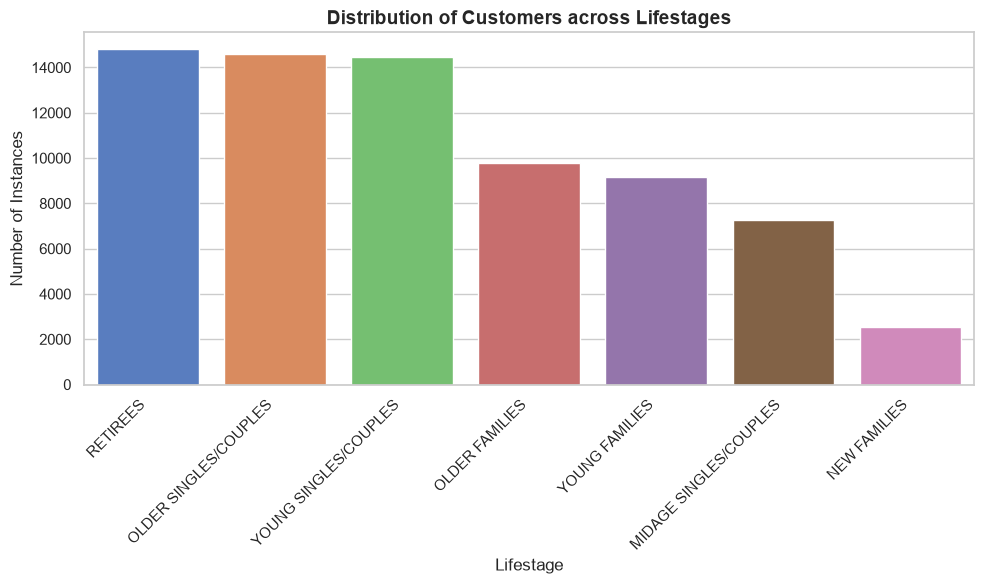

In [10]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_purchase_beh, 
    x="LIFESTAGE", 
    order=df_purchase_beh["LIFESTAGE"].value_counts().index,
    palette="muted"
)

# Rotate the labels 45 degrees and align them to the right
plt.xticks(rotation=45, ha='right')

plt.title("Distribution of Customers across Lifestages", fontsize=14, fontweight='bold')
plt.xlabel("Lifestage", fontsize=12)
plt.ylabel("Number of Instances", fontsize=12)

plt.tight_layout()
plt.show()

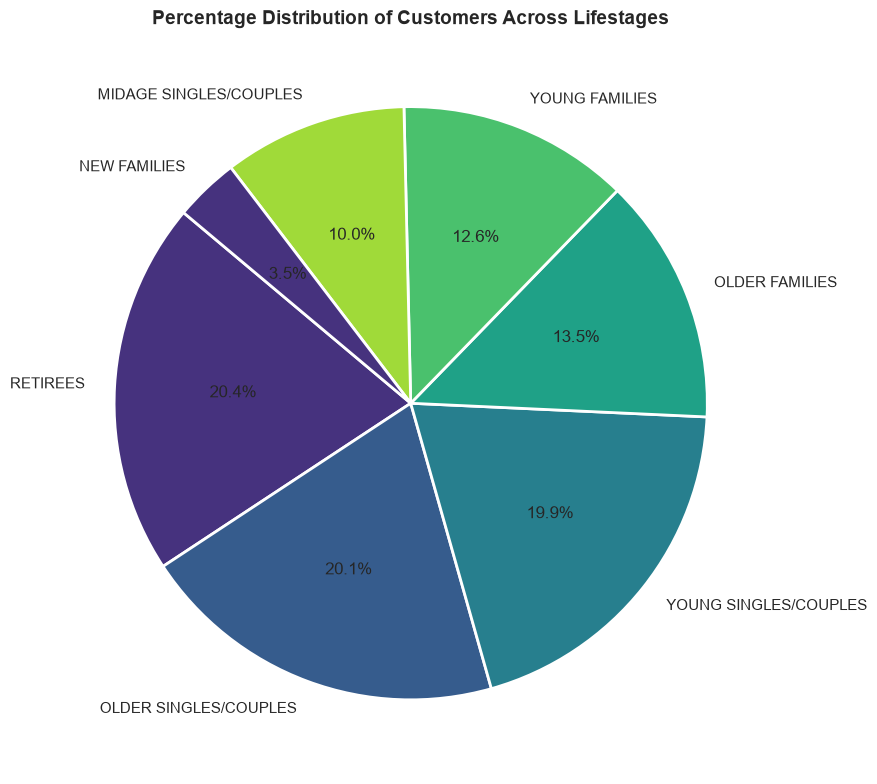

In [11]:
# counting
counts = df_purchase_beh["LIFESTAGE"].value_counts()

sns.set_theme(style="whitegrid")
colors = sns.color_palette("viridis")

plt.figure(figsize=(10, 8))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%',       # This automatically calculates and shows the percentages
    startangle=140,          # Rotates the start of the pie for a better layout
    colors=colors,           # Applies the seaborn colors
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Adds clean white lines between slices
)


plt.title("Percentage Distribution of Customers Across Lifestages", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
df_purchase_beh["PREMIUM_CUSTOMER"].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

C:\Users\gohar\AppData\Local\Temp\ipykernel_11244\203622162.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


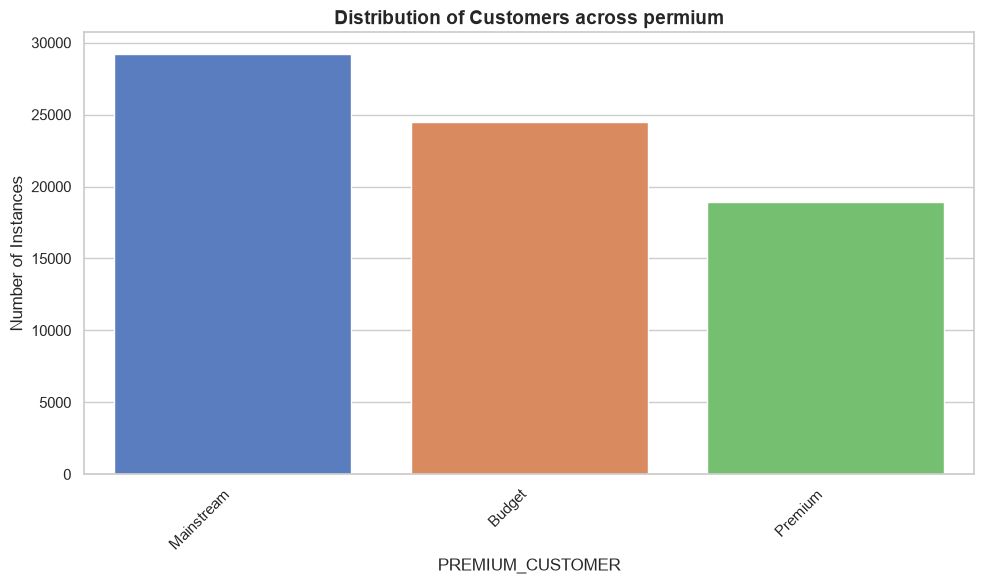

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_purchase_beh, 
    x="PREMIUM_CUSTOMER", 
    order=df_purchase_beh["PREMIUM_CUSTOMER"].value_counts().index,
    palette="muted"
)

# Rotate the labels 45 degrees and align them to the right
plt.xticks(rotation=45, ha='right')

plt.title("Distribution of Customers across permium", fontsize=14, fontweight='bold')
plt.xlabel("PREMIUM_CUSTOMER", fontsize=12)
plt.ylabel("Number of Instances", fontsize=12)

plt.tight_layout()
plt.show()

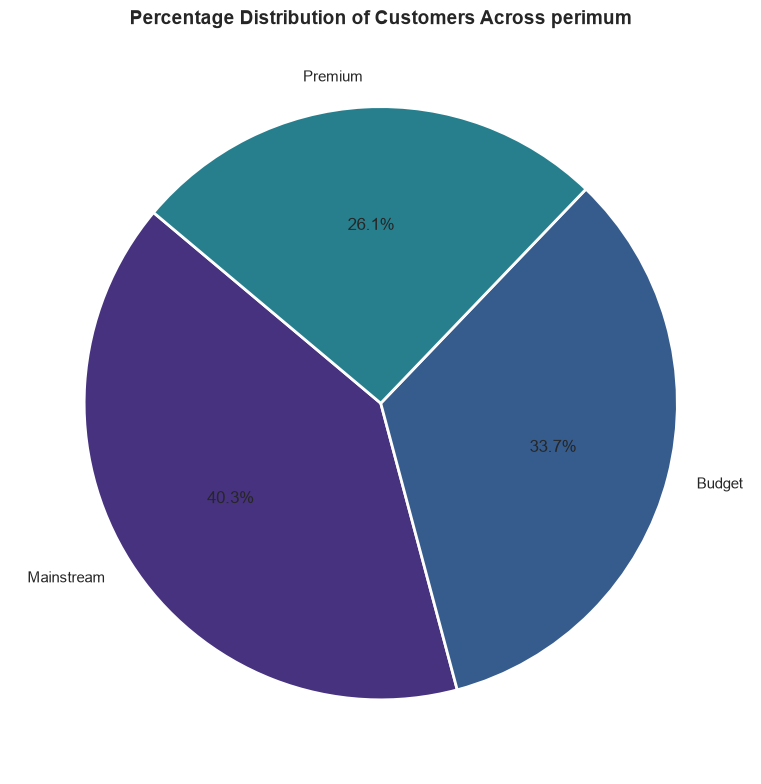

In [14]:
# counting
counts = df_purchase_beh["PREMIUM_CUSTOMER"].value_counts()

sns.set_theme(style="whitegrid")
colors = sns.color_palette("viridis")

plt.figure(figsize=(10, 8))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%',       # This automatically calculates and shows the percentages
    startangle=140,          # Rotates the start of the pie for a better layout
    colors=colors,           # Applies the seaborn colors
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Adds clean white lines between slices
)


plt.title("Percentage Distribution of Customers Across perimum", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### next step 
To study them together as 
 - Absolute Cross-Tabulation
 - Side by Side bar chart


In [15]:
cross_tab = pd.crosstab(
    index=df_purchase_beh["LIFESTAGE"], 
    columns=df_purchase_beh["PREMIUM_CUSTOMER"], 
    margins=True,       # Adds the "All" row/column for totals
    margins_name="Total"
)

print(cross_tab)

PREMIUM_CUSTOMER        Budget  Mainstream  Premium  Total
LIFESTAGE                                                 
MIDAGE SINGLES/COUPLES    1504        3340     2431   7275
NEW FAMILIES              1112         849      588   2549
OLDER FAMILIES            4675        2831     2274   9780
OLDER SINGLES/COUPLES     4929        4930     4750  14609
RETIREES                  4454        6479     3872  14805
YOUNG FAMILIES            4017        2728     2433   9178
YOUNG SINGLES/COUPLES     3779        8088     2574  14441
Total                    24470       29245    18922  72637


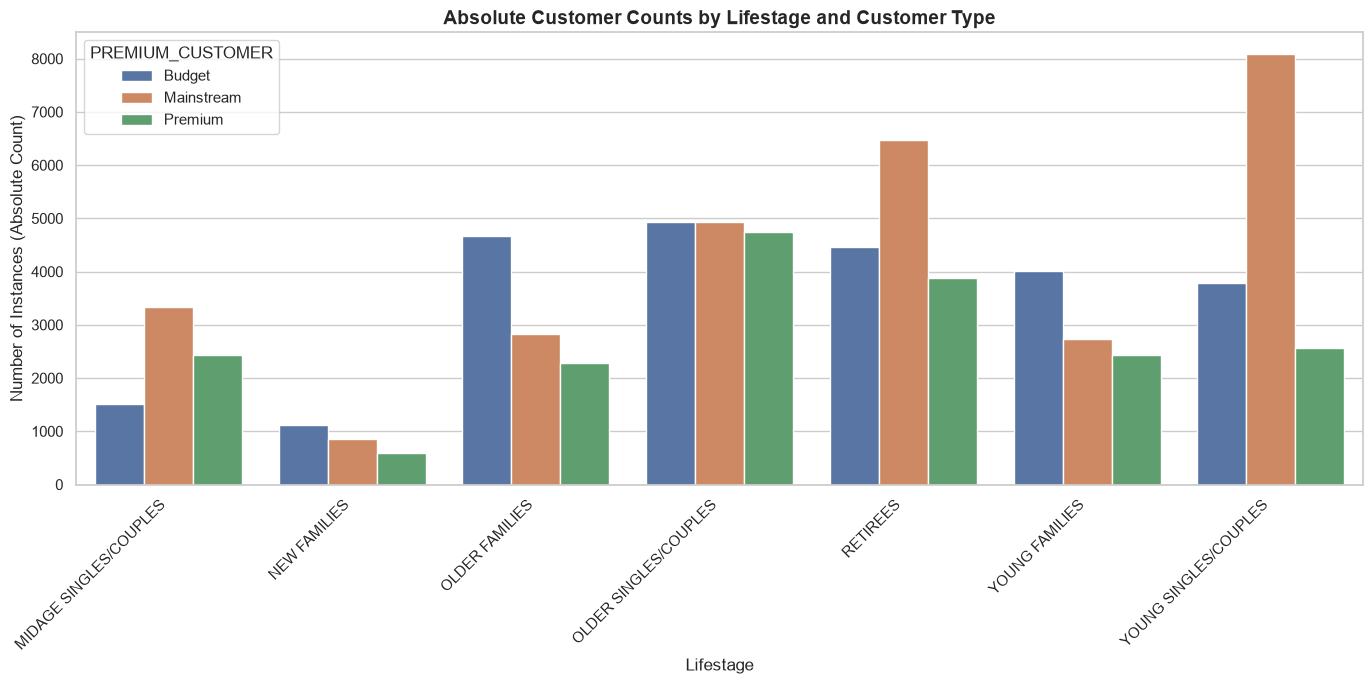

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

sns.countplot(
    data=df_purchase_beh,
    x="LIFESTAGE",
    hue="PREMIUM_CUSTOMER",  
    palette="deep"
)


plt.title("Absolute Customer Counts by Lifestage and Customer Type", fontsize=14, fontweight='bold')
plt.xlabel("Lifestage", fontsize=12)
plt.ylabel("Number of Instances (Absolute Count)", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### next steps 
- using the percentage method to expain the data so the the effect of the biasness (one category having the more instances) can be reduced

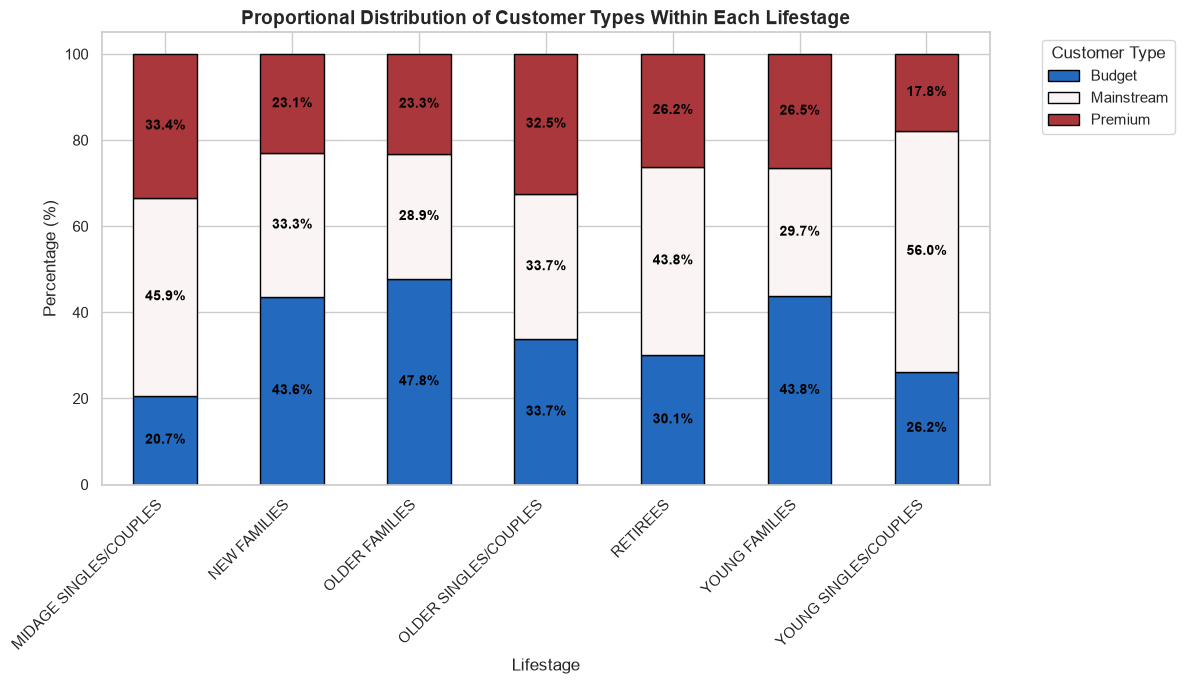

In [18]:
# cross_tab_pct = pd.crosstab(
#     index=df_purchase_beh["LIFESTAGE"], 
#     columns=df_purchase_beh["PREMIUM_CUSTOMER"], 
#     normalize='index'
# ) * 100

# print("--- Percentage Cross-Tabulation ---")
# print(cross_tab_pct)

# ax = cross_tab_pct.plot(
#     kind='bar', 
#     stacked=True, 
#     figsize=(12, 7), 
#     colormap='vlag', # Gives a clean, contrasting color palette
#     edgecolor='black'
# )

# plt.title("Proportional Distribution of Customer Types Within Each Lifestage", fontsize=14, fontweight='bold')
# plt.xlabel("Lifestage", fontsize=12)
# plt.ylabel("Percentage (%)", fontsize=12)
# plt.xticks(rotation=45, ha='right')

# plt.legend(title="Customer Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
# plt.show()

cross_tab_pct = pd.crosstab(
    index=df_purchase_beh["LIFESTAGE"], 
    columns=df_purchase_beh["PREMIUM_CUSTOMER"], 
    normalize='index'
) * 100

ax = cross_tab_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    colormap='vlag', 
    edgecolor='black'
)

for patch in ax.patches:
    width, height = patch.get_width(), patch.get_height()
    x, y = patch.get_xy() 
    
    # Only label segments that are large enough to fit text (e.g., > 1%)
    if height > 1.0:
        ax.annotate(
            f'{height:.1f}%', # Formats the number to 1 decimal place
            (x + width/2, y + height/2), 
            ha='center', 
            va='center', 
            color='black', # Change to 'white' if your palette blocks are very dark
            fontweight='bold',
            fontsize=10
        )


plt.title("Proportional Distribution of Customer Types Within Each Lifestage", fontsize=14, fontweight='bold')
plt.xlabel("Lifestage", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')


plt.legend(title="Customer Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

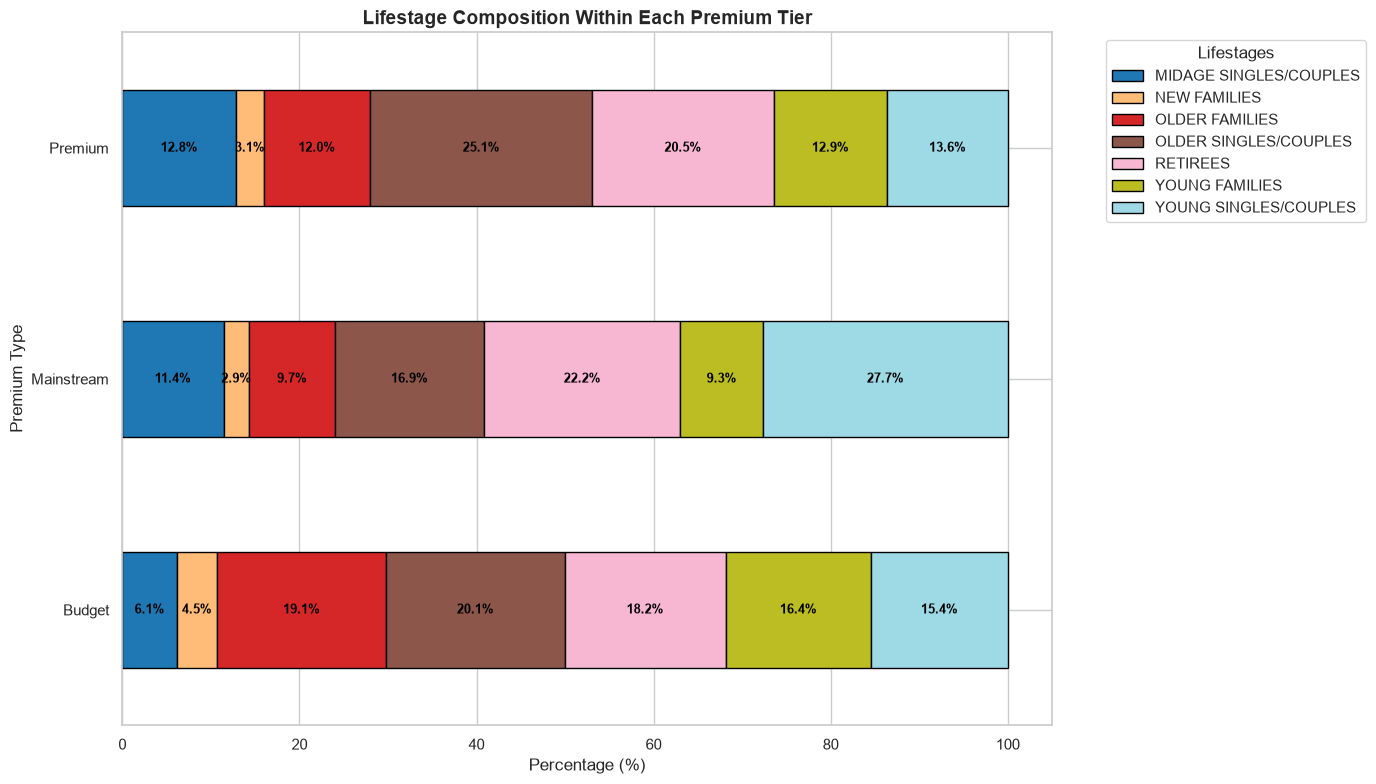

In [20]:
cross_tab_pct = pd.crosstab(
    index=df_purchase_beh["PREMIUM_CUSTOMER"], # This is now the base/rows
    columns=df_purchase_beh["LIFESTAGE"],        # This breaks down inside the bars
    normalize='index'
) * 100
ax = cross_tab_pct.plot(
    kind='barh', 
    stacked=True, 
    figsize=(14, 8), 
    colormap='tab20', # 'tab20' is great here because you have many lifestage categories
    edgecolor='black'
)

for patch in ax.patches:
    width, height = patch.get_width(), patch.get_height()
    x, y = patch.get_xy() 
    
   
    if width > 2.0:
        ax.annotate(
            f'{width:.1f}%', 
            (x + width/2, y + height/2), 
            ha='center', 
            va='center', 
            color='black', 
            fontweight='bold',
            fontsize=9
        )

plt.title("Lifestage Composition Within Each Premium Tier", fontsize=14, fontweight='bold')
plt.xlabel("Percentage (%)", fontsize=12)
plt.ylabel("Premium Type", fontsize=12)

# Move the legend outside to keep it clean, as there will be many lifestage labels
plt.legend(title="Lifestages", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Key Insights

### 1. Premium Tier Driven by Older Customers

* **Older Singles/Couples (25.1%)** and **Retirees (20.5%)** account for over **45%** of Premium customers.
* These segments represent the strongest contributors to the high-margin premium category.

### 2. Mainstream Tier Led by Young Adults

* **Young Singles/Couples** make up **27.7%** of the Mainstream tier, the highest concentration of any lifestage segment.
* This group is the primary driver of mainstream sales volume.

### 3. Budget Tier Favored by Families

* **Older Families (19.1%)** and **Young Families (16.4%)** show their highest representation in the Budget tier.
* Family households demonstrate a strong preference for value-oriented products.

## Business Recommendations

### Premium: Target Affluent Older Consumers

* Focus marketing efforts on older adults and retirees.
* Emphasize quality, convenience, exclusivity, and premium experiences.

### Mainstream: Appeal to Young Singles/Couples

* Align products with current trends and modern lifestyles.
* Utilize social media, digital marketing, and contemporary branding.

### Budget: Deliver Family Value

* Offer family-sized packs and bulk-buy discounts.
* Highlight affordability, savings, and value-for-money messaging.
